# 🥑 Hass Avocado Prices — Part 1: Get, Know, Clean & Explore

**Notebook scope:** Stages 1–3 of the [`DOCS/STRUCTURE.md`](../DOCS/STRUCTURE.md) pipeline —
*get the data → know the data → clean & validate → exploratory data analysis (EDA)*.

This is the **look-before-you-leap** stage. We deliberately **stop before** the deep dive
(statistical testing, prediction, causal inference) so the data can be understood first.
Those follow in later notebooks / scripts:

| Stage | This notebook | Later |
|---|---|---|
| 1 · Ingestion (get & know) | ✅ | |
| 2 · Cleaning & validation | ✅ | |
| 3 · Exploratory Data Analysis | ✅ | |
| Path A · Statistical testing | | `src/analysis_paths_a.py` |
| Path B · Forecasting | | `src/forward_forecast.py`, `src/sarimax_forecast.py` |
| Path C · Causal (elasticity) | | `src/causal_study.py` |

> **Dataset.** Weekly multi-outlet US retail scan data for Hass avocados (grocery, mass, club,
> drug, dollar, military), 2015–2018. *Average Price* is **per single avocado**, even when sold
> in bags. PLU codes 4046 / 4225 / 4770 = small / large / xlarge Hass; greenskins excluded.

## Stage 0 — Problem Framing (recap)

Before touching the data, the questions we are exploring toward (the "So What?" anchors):

1. **Descriptive/Diagnostic —** What are the **price patterns**, and does price **differ by
   region or type**?
2. **Predictive —** Can we **forecast** the price?
3. **Causal —** What happens to demand **if we change** the price?

**Working hypotheses to check during EDA:**
- H1: Organic avocados are priced above conventional.
- H2: Price varies meaningfully by region.
- H3: Price is seasonal (an annual cycle).
- H4: Price and volume move inversely (supply gluts depress price).

In [1]:
# Core stack
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# Consistent, limited palette (STRUCTURE.md exhibit rule)
ACCENT, CONV, GREY = "#2f7a43", "#8d6e63", "#9e9e9e"
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "figure.figsize": (9, 4.5)})
print("Environment ready — pandas", pd.__version__)

Environment ready — pandas 3.0.3


---
## Stage 1 — Get the Data

**Immutability rule:** we load the raw file read-only and never overwrite it. First we simply
*get it in and look at its shape* before forming any opinion.

In [2]:
# Robust path resolution so the notebook runs from either the project root or /notebooks
candidates = [
    "data/raw/avocado_raw.csv", "../data/raw/avocado_raw.csv",
    "avocado.csv/avocado.csv", "../avocado.csv/avocado.csv",
]
DATA = next((p for p in candidates if os.path.exists(p)), None)
assert DATA, "Could not locate the avocado CSV — check the path candidates."
df = pd.read_csv(DATA)
print(f"Loaded: {DATA}")
print(f"Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

Loaded: data/raw/avocado_raw.csv
Shape : 18,249 rows  ×  14 columns


In [3]:
# First look — the raw rows
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


## Know the Data — Structure & Types

Before cleaning, understand **what each column is**, its **type**, and whether the values look
sane. Three quick lenses: `info()` (types & non-nulls), `describe()` (numeric ranges), and a
scan of the categorical columns.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  str    
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  str    
 12  year          18249 non-null  int64  
 13  region        18249 non-null  str    
dtypes: float64(9), int64(2), str(3)
memory usage: 1.9 MB


In [5]:
# Numeric summary — check ranges for anything impossible (negative price/volume, etc.)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,18249.0,24.232232,1.548104e+01,0.00,10.00,24.00,38.00,52.00
AveragePrice,18249.0,1.405978,4.026766e-01,0.44,1.10,1.37,1.66,3.25
Total Volume,18249.0,850644.013009,3.453545e+06,84.56,10838.58,107376.76,432962.29,62505646.52
4046,18249.0,293008.424531,1.264989e+06,0.00,854.07,8645.30,111020.20,22743616.17
4225,18249.0,295154.568356,1.204120e+06,0.00,3008.78,29061.02,150206.86,20470572.61
4770,18249.0,22839.735993,1.074641e+05,0.00,0.00,184.99,6243.42,2546439.11
Total Bags,18249.0,239639.202060,9.862424e+05,0.00,5088.64,39743.83,110783.37,19373134.37
Small Bags,18249.0,182194.686696,7.461785e+05,0.00,2849.42,26362.82,83337.67,13384586.80
Large Bags,18249.0,54338.088145,2.439660e+05,0.00,127.47,2647.71,22029.25,5719096.61
XLarge Bags,18249.0,3106.426507,1.769289e+04,0.00,0.00,0.00,132.50,551693.65


In [6]:
# Categorical / temporal overview
print("TYPE:", df['type'].unique().tolist())
print(f"\nREGION: {df['region'].nunique()} unique values")
print(df['region'].value_counts().head(10).to_string())
print("\nYEAR:", sorted(df['year'].unique().tolist()))
print("\nDate (as string) min/max:", df['Date'].min(), "->", df['Date'].max())

TYPE: ['conventional', 'organic']

REGION: 54 unique values
region
Albany                 338
Atlanta                338
BaltimoreWashington    338
Boise                  338
Boston                 338
BuffaloRochester       338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338

YEAR: [2015, 2016, 2017, 2018]

Date (as string) min/max: 2015-01-04 -> 2018-03-25


### Data dictionary

| Column | Meaning | Type |
|---|---|---|
| `Unnamed: 0` | Row index carried over from the source export (drop it) | int |
| `Date` | Week-ending date of the observation | date |
| `AveragePrice` | Average price **per single avocado** that week | float ($) |
| `Total Volume` | Total avocados sold | float (units) |
| `4046` / `4225` / `4770` | Volume of small / large / xlarge Hass (PLU codes) | float |
| `Total Bags` / `Small`/`Large`/`XLarge Bags` | Volume sold in bags, by bag size | float |
| `type` | `conventional` or `organic` | category |
| `year` | Calendar year | int |
| `region` | City, sub-region, or aggregate (e.g. `TotalUS`) | category |

> ⚠️ **Watch-out spotted early:** `region` **mixes granularities** — individual cities
> (`Albany`) sit alongside aggregates (`TotalUS`, `West`, `California`). We must flag these so we
> never accidentally sum a city into its own region total.

---
## Stage 2 — Clean & Validate

Following the STRUCTURE.md Stage 2 gate checklist: drop the junk index, cast types, check
**nulls**, **duplicates**, and **business rules**, and flag the aggregate-region trap.

In [7]:
# 1) Drop the leftover index column and cast types
if df.columns[0].startswith("Unnamed"):
    df = df.drop(columns=df.columns[0])
df["Date"] = pd.to_datetime(df["Date"])
df["type"] = df["type"].astype("category")
df["region"] = df["region"].astype("category")
print("Types cast. Date range:", df["Date"].min().date(), "->", df["Date"].max().date())

Types cast. Date range: 2015-01-04 -> 2018-03-25


In [8]:
# 2) Missing values — assess per column
nulls = df.isnull().sum()
print("Nulls per column:")
print(nulls.to_string())
print(f"\nTotal missing cells: {nulls.sum()}")

Nulls per column:
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0

Total missing cells: 0


In [9]:
# 3) Duplicates
exact = df.duplicated().sum()
# a logical duplicate = same date + type + region should be unique
key_dupes = df.duplicated(subset=["Date", "type", "region"]).sum()
print(f"Exact duplicate rows        : {exact}")
print(f"Duplicate (Date,type,region): {key_dupes}")

Exact duplicate rows        : 0
Duplicate (Date,type,region): 0


In [10]:
# 4) Business-rule validation — fail loudly if violated
assert (df["AveragePrice"] > 0).all(),  "Found non-positive price!"
assert (df["Total Volume"] >= 0).all(), "Found negative volume!"
# volume components should roughly not exceed the total (allow tiny rounding)
comp = df[["4046","4225","4770","Total Bags"]].sum(axis=1)
over = (comp > df["Total Volume"] * 1.01).sum()
print("price > 0            : PASS")
print("volume >= 0          : PASS")
print(f"components <= total  : {len(df)-over}/{len(df)} rows OK ({over} minor overages)")

price > 0            : PASS
volume >= 0          : PASS
components <= total  : 18249/18249 rows OK (0 minor overages)


In [11]:
# 5) Flag aggregate regions so city-level comparisons stay clean
AGG_REGIONS = {"TotalUS","West","Northeast","SouthCentral","Southeast","GreatLakes",
               "Midsouth","Plains","California","WestTexNewMexico","NorthernNewEngland"}
df["is_aggregate_region"] = df["region"].isin(AGG_REGIONS)
print(f"Aggregate/multi-city rows flagged: {df['is_aggregate_region'].sum():,} "
      f"({df['is_aggregate_region'].mean()*100:.0f}% of data)")
print(f"City-level rows for fair comparisons: {(~df['is_aggregate_region']).sum():,}")

Aggregate/multi-city rows flagged: 3,715 (20% of data)
City-level rows for fair comparisons: 14,534


In [12]:
# 6) Light feature prep for EDA (temporal) + save the cleaned copy
df["month"] = df["Date"].dt.month
df["week"]  = df["Date"].dt.isocalendar().week.astype(int)
os.makedirs("data/processed", exist_ok=True) if os.path.isdir("data") else None
out = "data/processed/avocado_clean.csv" if os.path.isdir("data") else "../data/processed/avocado_clean.csv"
df.to_csv(out, index=False)
print("Saved cleaned data ->", out)

Saved cleaned data ->

 data/processed/avocado_clean.csv


### ✅ Stage 2 summary (cleaning log)

- **Nulls:** none — no imputation needed.
- **Duplicates:** none (exact or on `Date × type × region`).
- **Business rules:** all prices > 0, all volumes ≥ 0; volume components reconcile to the total.
- **Type casting:** `Date`→datetime, `type`/`region`→category.
- **Key fix:** added `is_aggregate_region` to separate cities from roll-ups.

This is an unusually clean dataset — so almost all our effort can go into **understanding** it.

---
## Stage 3 — Exploratory Data Analysis (EDA)

EDA here is **hypothesis-driven** (H1–H4 from Stage 0), not a random chart dump. Each exhibit is
followed by a plain-language **So What**.

### 3.1 · How is price distributed overall, and by type? *(tests H1)*

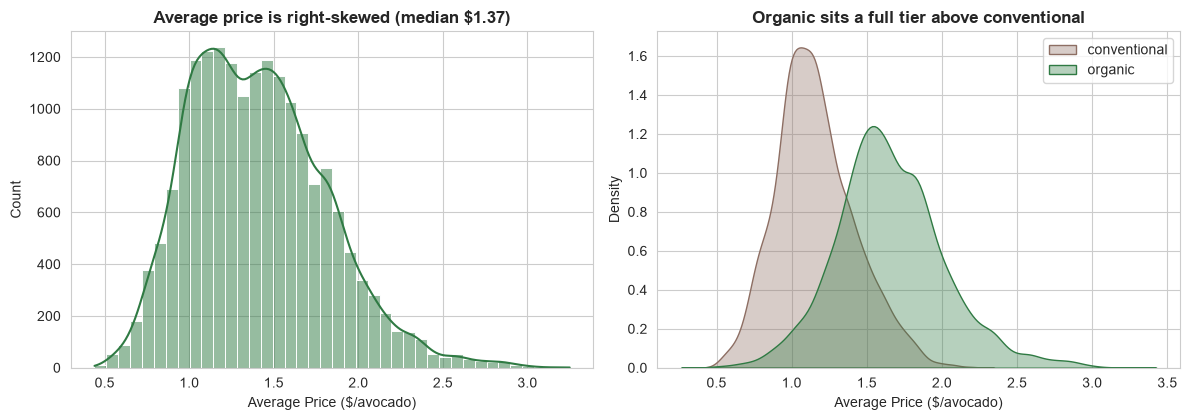

              median   mean    std
type                              
conventional    1.13  1.158  0.263
organic         1.63  1.654  0.364


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
sns.histplot(df["AveragePrice"], bins=40, kde=True, color=ACCENT, ax=ax[0])
ax[0].set_title(f"Average price is right-skewed (median ${df['AveragePrice'].median():.2f})")
ax[0].set_xlabel("Average Price ($/avocado)")
sns.kdeplot(df[df.type=="conventional"]["AveragePrice"], ax=ax[1], label="conventional", color=CONV, fill=True, alpha=.35)
sns.kdeplot(df[df.type=="organic"]["AveragePrice"], ax=ax[1], label="organic", color=ACCENT, fill=True, alpha=.35)
ax[1].set_title("Organic sits a full tier above conventional")
ax[1].set_xlabel("Average Price ($/avocado)"); ax[1].legend()
plt.tight_layout(); plt.show()

print(df.groupby("type", observed=True)["AveragePrice"].agg(["median","mean","std"]).round(3))

> **So What (H1 ✔):** Organic's median (~\$1.63) is roughly **1.4× conventional's** (~\$1.13). The
> two lines barely overlap → **type must be the first split** in any later model. We'll quantify the
> premium formally in Path A.

### 3.2 · Does price vary by region? *(tests H2)*

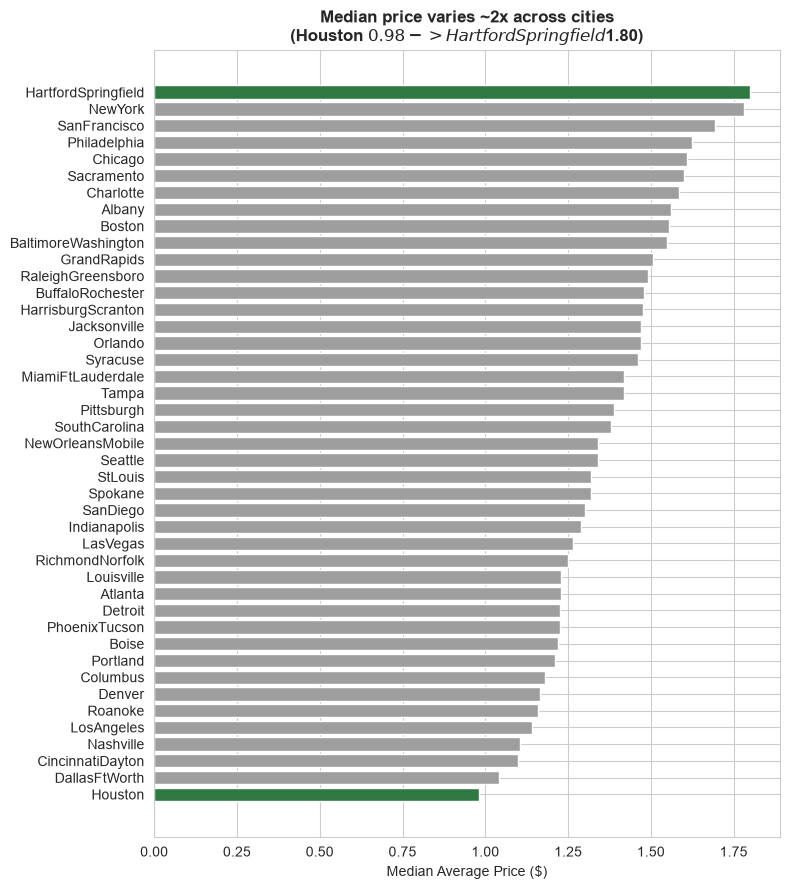

In [14]:
city = df[~df["is_aggregate_region"]]
reg_med = city.groupby("region", observed=True)["AveragePrice"].median().sort_values()
fig, ax = plt.subplots(figsize=(8, 9))
colors = [ACCENT if v in (reg_med.min(), reg_med.max()) else GREY for v in reg_med.values]
ax.barh(reg_med.index.astype(str), reg_med.values, color=colors)
ax.set_title(f"Median price varies ~2x across cities\n({reg_med.idxmin()} ${reg_med.min():.2f} -> {reg_med.idxmax()} ${reg_med.max():.2f})")
ax.set_xlabel("Median Average Price ($)")
plt.tight_layout(); plt.show()

> **So What (H2 ✔):** City-level median price spans **~2×**, from Houston (~\$0.98) to
> Hartford–Springfield (~\$1.80). Region is a real driver worth a formal test (ANOVA in Path A).

### 3.3 · Is price seasonal? *(tests H3)*

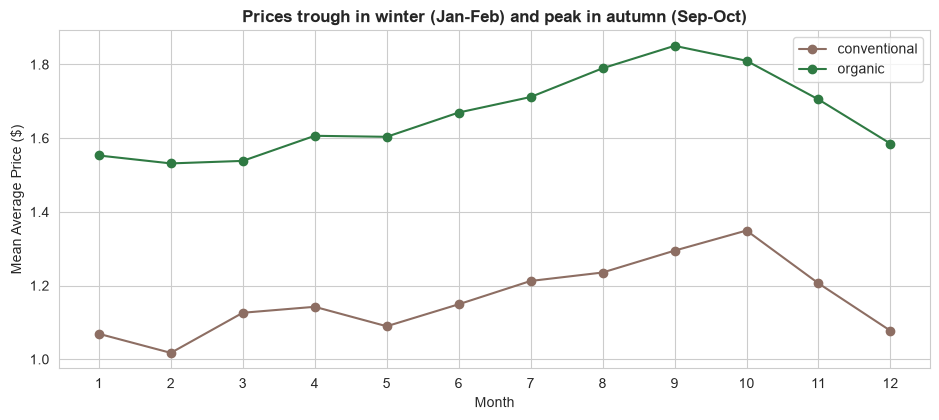

In [15]:
monthly = df.groupby(["month","type"], observed=True)["AveragePrice"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9.5, 4.3))
for t, c in [("conventional", CONV), ("organic", ACCENT)]:
    d = monthly[monthly.type==t]
    ax.plot(d["month"], d["AveragePrice"], marker="o", label=t, color=c)
ax.set_xticks(range(1,13)); ax.set_xlabel("Month"); ax.set_ylabel("Mean Average Price ($)")
ax.set_title("Prices trough in winter (Jan-Feb) and peak in autumn (Sep-Oct)")
ax.legend(); plt.tight_layout(); plt.show()

> **So What (H3 ✔):** A clear annual cycle — cheap in winter, dear in autumn — for **both** types.
> This seasonality is *known ahead of time*, which is what makes forecasting feasible (Path B).

### 3.4 · Do price and volume move together? *(tests H4)*

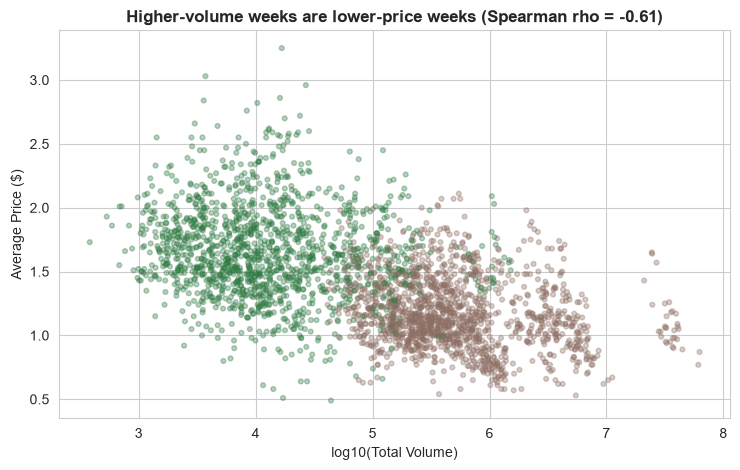

In [16]:
corr = df[["AveragePrice","Total Volume"]].corr(method="spearman").iloc[0,1]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
samp = df.sample(3000, random_state=42)
ax.scatter(np.log10(samp["Total Volume"]+1), samp["AveragePrice"],
           c=samp["type"].map({"conventional":CONV,"organic":ACCENT}), s=12, alpha=.35)
ax.set_xlabel("log10(Total Volume)"); ax.set_ylabel("Average Price ($)")
ax.set_title(f"Higher-volume weeks are lower-price weeks (Spearman rho = {corr:.2f})")
plt.tight_layout(); plt.show()

> **So What (H4 ✔):** Price and volume are **inversely** related (ρ ≈ −0.61) — classic supply
> behavior (gluts push prices down). Crucially, this also flags a **causal caveat**: because price
> and volume are jointly determined, a naive correlation ≠ the true price elasticity — which is
> exactly why Path C uses instrumental variables.

### 3.5 · How do all the numeric fields relate?

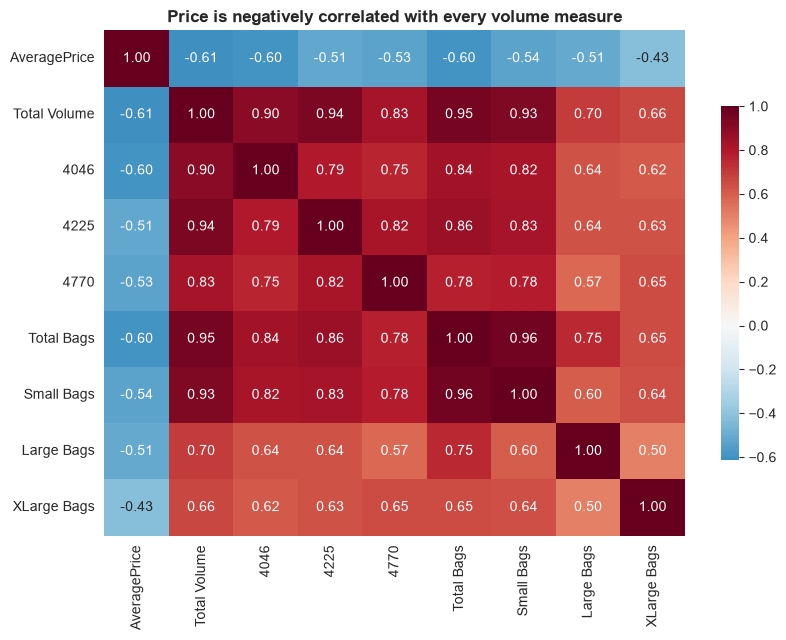

In [17]:
num = ["AveragePrice","Total Volume","4046","4225","4770","Total Bags",
       "Small Bags","Large Bags","XLarge Bags"]
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(df[num].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, cbar_kws={"shrink":.7}, ax=ax)
ax.set_title("Price is negatively correlated with every volume measure")
plt.tight_layout(); plt.show()

> **So What:** Price is negatively correlated with *all* volume columns, while the volume columns
> are strongly positively correlated with each other (they're components of the same total →
> multicollinearity to handle later if we use them together in a model).

---
## EDA Summary & What's Next

**Preliminary findings (all four hypotheses supported):**

| # | Hypothesis | Verdict | Evidence |
|---|---|---|---|
| H1 | Organic > conventional price | ✅ | ~1.4× higher median, distributions barely overlap |
| H2 | Price varies by region | ✅ | ~2× spread across cities (Houston → Hartford) |
| H3 | Price is seasonal | ✅ | Winter trough, autumn peak, both types |
| H4 | Price ↔ volume inverse | ✅ | Spearman ρ ≈ −0.61 |

**Data-quality verdict:** clean (no nulls, no dupes, rules pass). The one structural gotcha —
mixed region granularity — is handled via `is_aggregate_region`.

**Now we're ready to deep-dive** (later notebooks / `src/` scripts):
- **Path A —** formally test the type & region differences (t-test, ANOVA, effect sizes).
- **Path B —** forecast price (1-week-ahead ML + SARIMAX), adding holiday/event features.
- **Path C —** estimate the *causal* price elasticity of demand with instrumental variables.

> The cleaned dataset has been saved to `data/processed/avocado_clean.csv` for those steps.